# Task 03 — Feature Engineering Mastery
**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Author:** Ateeq

Building on Task 02's cleaned data, this notebook demonstrates advanced
feature engineering: skew-reducing transformations, interaction/ratio
features, polynomial features, clustering-based features, multiple
categorical encoding strategies, feature selection, dimensionality
reduction for visualization, and a baseline-vs-engineered model
comparison that proves the engineered features add real predictive value.

## 1. Setup

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_loader import prepare_clean_dataframe, basic_info
from src.preprocessing import (
    BASE_NUMERIC, add_basic_features, log_transform, add_interaction_features,
    add_polynomial_features, add_cluster_feature, frequency_encode, target_encode,
    mutual_information_ranking, get_feature_columns, split_data, pca_2d,
)
from src.modeling import (
    build_pipeline, evaluate_pipeline, compare_feature_sets, random_forest_feature_importance,
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

## 2. Load Cleaned Data (Task 02 baseline)

In [2]:
df = prepare_clean_dataframe("data/Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
print(basic_info(df))
df.head()

Shape: (7043, 21)
{'n_rows': 7043, 'n_cols': 21, 'n_duplicates': 22, 'missing_per_column': {'gender': 0, 'SeniorCitizen': 0, 'Partner': 0, 'Dependents': 0, 'tenure': 0, 'PhoneService': 0, 'MultipleLines': 0, 'InternetService': 0, 'OnlineSecurity': 0, 'OnlineBackup': 0, 'DeviceProtection': 0, 'TechSupport': 0, 'StreamingTV': 0, 'StreamingMovies': 0, 'Contract': 0, 'PaperlessBilling': 0, 'PaymentMethod': 0, 'MonthlyCharges': 0, 'TotalCharges': 0, 'Churn': 0, 'Churn_binary': 0}}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 3. Numeric Transformations — Reducing Skew

`TotalCharges` is strongly right-skewed. A log1p transform pulls in the
long tail, which helps linear models that assume roughly symmetric,
homoscedastic numeric inputs.

Skewness before: 0.963 | after log1p: -0.824


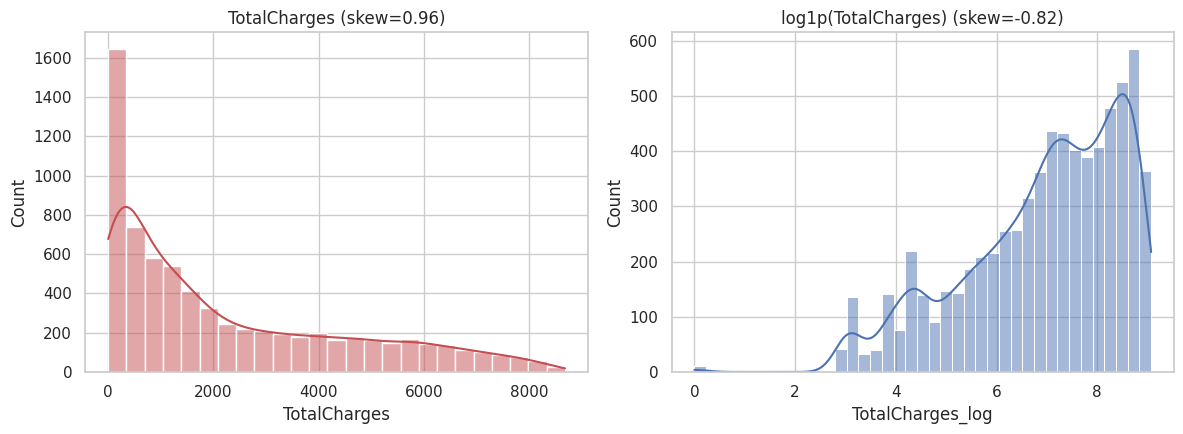

In [3]:
df = add_basic_features(df)
skew_before = df["TotalCharges"].skew()
df = log_transform(df, "TotalCharges")
skew_after = df["TotalCharges_log"].skew()
print(f"Skewness before: {skew_before:.3f} | after log1p: {skew_after:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["TotalCharges"], kde=True, ax=axes[0], color="#c44e52")
axes[0].set_title(f"TotalCharges (skew={skew_before:.2f})")
sns.histplot(df["TotalCharges_log"], kde=True, ax=axes[1], color="#4c72b0")
axes[1].set_title(f"log1p(TotalCharges) (skew={skew_after:.2f})")
savefig("01_skew_before_after_log_transform")
plt.show()

## 4. Interaction & Ratio Features

- `tenure_x_monthly`: captures customers who are both long-tenured AND high-spend
- `charges_per_service`: normalizes spend by how many services a customer has
- `spend_to_tenure_ratio`: an alternative, smoothed spend-rate signal

In [4]:
df = add_interaction_features(df)
df[["tenure", "MonthlyCharges", "tenure_x_monthly", "num_services", "charges_per_service", "spend_to_tenure_ratio"]].head()

,tenure,MonthlyCharges,tenure_x_monthly,num_services,charges_per_service,spend_to_tenure_ratio
0,1,29.85,29.85,2,14.9250,14.925000
1,34,56.95,1936.30,4,14.2375,53.985714
2,2,53.85,107.70,4,13.4625,36.050000
3,45,42.30,1903.50,4,10.5750,40.016304
4,2,70.70,141.40,2,35.3500,50.550000


## 5. Polynomial Features

Degree-2 polynomial expansion of `tenure` and `MonthlyCharges` adds
`tenure^2`, `MonthlyCharges^2`, and the `tenure x MonthlyCharges`
interaction term, letting a linear model capture simple non-linear and
interaction effects without switching to a fully non-linear model.

In [5]:
df = add_polynomial_features(df, ["tenure", "MonthlyCharges"], degree=2)
poly_cols = [c for c in df.columns if "^" in c or " " in c]
print("New polynomial columns:", poly_cols)
df[poly_cols].head()

New polynomial columns: ['tenure^2', 'tenure MonthlyCharges', 'MonthlyCharges^2']


,tenure^2,tenure MonthlyCharges,MonthlyCharges^2
0,1.0,29.85,891.0225
1,1156.0,1936.30,3243.3025
2,4.0,107.70,2899.8225
3,2025.0,1903.50,1789.2900
4,4.0,141.40,4998.4900


## 6. Clustering-Based Feature

KMeans (k=4) is fit on the standardized base numeric features to create
a `customer_segment` label — a compact, non-linear summary of a
customer's overall usage profile that a linear model couldn't otherwise
construct on its own.

customer_segment
2    2276
1    1904
0    1703
3    1160
Name: count, dtype: int64


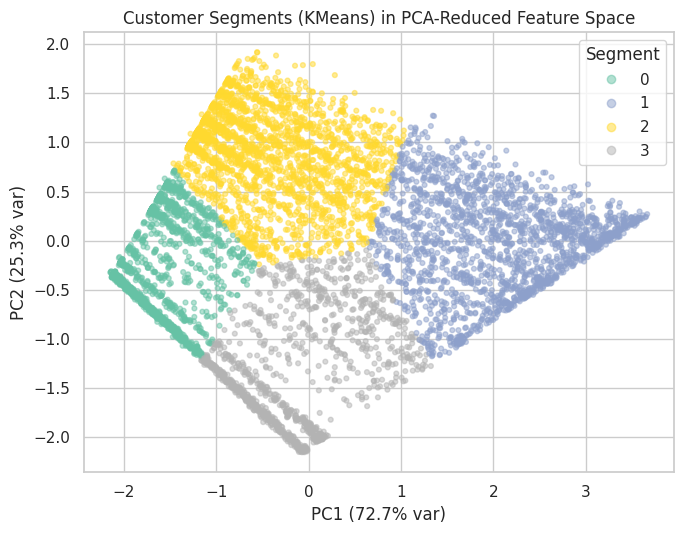

In [6]:
df, kmeans_model = add_cluster_feature(df, BASE_NUMERIC, n_clusters=4)
print(df["customer_segment"].value_counts())

components, var_ratio = pca_2d(df, BASE_NUMERIC)
plt.figure(figsize=(7, 5.5))
scatter = plt.scatter(components[:, 0], components[:, 1], c=df["customer_segment"].astype(int),
                       cmap="Set2", alpha=0.5, s=12)
plt.xlabel(f"PC1 ({var_ratio[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({var_ratio[1]*100:.1f}% var)")
plt.title("Customer Segments (KMeans) in PCA-Reduced Feature Space")
plt.legend(*scatter.legend_elements(), title="Segment")
savefig("02_cluster_segments_pca")
plt.show()

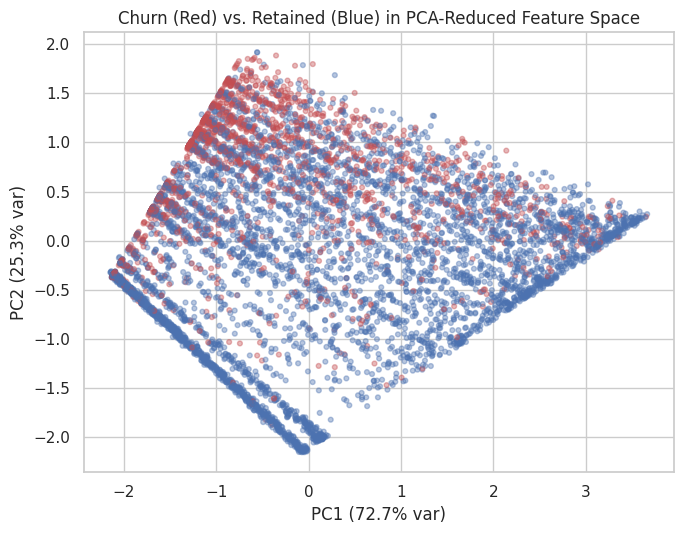

In [7]:
plt.figure(figsize=(7, 5.5))
churn_colors = df["Churn"].map({"Yes": "#c44e52", "No": "#4c72b0"})
plt.scatter(components[:, 0], components[:, 1], c=churn_colors, alpha=0.4, s=12)
plt.xlabel(f"PC1 ({var_ratio[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({var_ratio[1]*100:.1f}% var)")
plt.title("Churn (Red) vs. Retained (Blue) in PCA-Reduced Feature Space")
savefig("03_churn_pca_scatter")
plt.show()

## 7. Categorical Encoding Strategies — Comparison

Three encodings are compared on `PaymentMethod` (a nominal, low-cardinality
feature): one-hot (used in the final pipeline), frequency encoding, and
smoothed target (mean) encoding.

In [8]:
encoding_demo = pd.DataFrame({
    "PaymentMethod": df["PaymentMethod"],
    "frequency_encoded": frequency_encode(df, "PaymentMethod"),
    "target_encoded": target_encode(df, "PaymentMethod"),
}).drop_duplicates().sort_values("target_encoded", ascending=False)
encoding_demo

,PaymentMethod,frequency_encoded,target_encoded
0,Electronic check,0.335794,0.452065
1,Mailed check,0.228880,0.191525
3,Bank transfer (automatic),0.219225,0.167731
6,Credit card (automatic),0.216101,0.153168


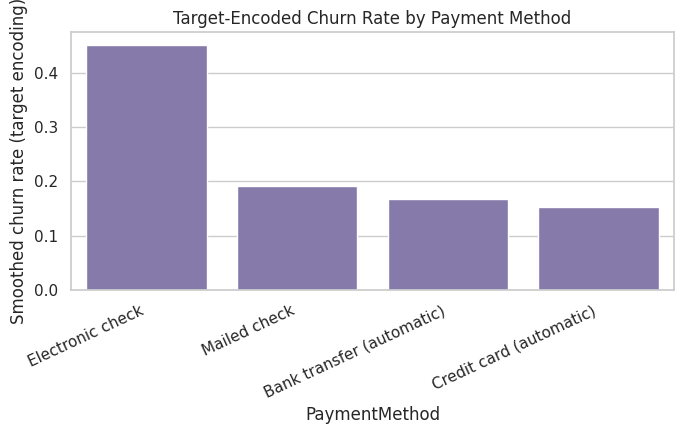

In [9]:
plt.figure(figsize=(7, 4.5))
sns.barplot(data=encoding_demo, x="PaymentMethod", y="target_encoded", color="#8172b2")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Smoothed churn rate (target encoding)")
plt.title("Target-Encoded Churn Rate by Payment Method")
savefig("04_target_encoding_by_payment_method")
plt.show()

**Choice for the final pipeline:** one-hot encoding is used for all
categorical features going into the model below, since the dataset's
categorical columns are all low-cardinality (2-4 categories) - one-hot
avoids the target-leakage risk of mean encoding at this scale, while
frequency/target encoding are demonstrated above as viable alternatives
for higher-cardinality features in future datasets.

## 8. Feature Selection — Mutual Information

In [10]:
engineered_numeric = BASE_NUMERIC + [
    "TotalCharges_log", "num_services", "avg_monthly_spend",
    "tenure_x_monthly", "charges_per_service", "spend_to_tenure_ratio",
] + poly_cols

mi_ranking = mutual_information_ranking(df, engineered_numeric)
mi_ranking

,feature,mutual_info
7,charges_per_service,0.088411
9,tenure^2,0.081653
0,tenure,0.071564
10,tenure MonthlyCharges,0.052740
6,tenure_x_monthly,0.050925
1,MonthlyCharges,0.047489
11,MonthlyCharges^2,0.044753
2,TotalCharges,0.044401
3,TotalCharges_log,0.043613
8,spend_to_tenure_ratio,0.037483


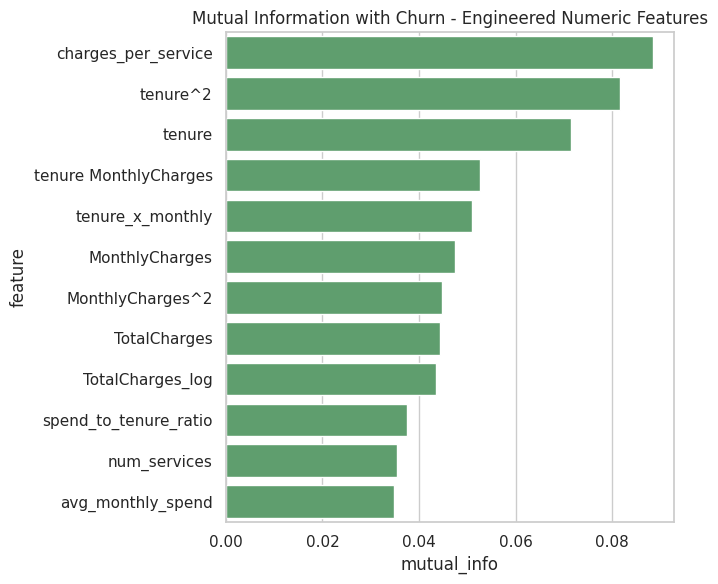

In [11]:
plt.figure(figsize=(7, 6))
sns.barplot(data=mi_ranking, x="mutual_info", y="feature", color="#55a868")
plt.title("Mutual Information with Churn - Engineered Numeric Features")
savefig("05_mutual_information_ranking")
plt.show()

## 9. Final Feature Set & Correlation Check

Final numeric features (12): ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_log', 'num_services', 'avg_monthly_spend', 'tenure_x_monthly', 'charges_per_service', 'spend_to_tenure_ratio', 'tenure^2', 'tenure MonthlyCharges', 'MonthlyCharges^2']
Final categorical features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'has_internet', 'customer_segment']


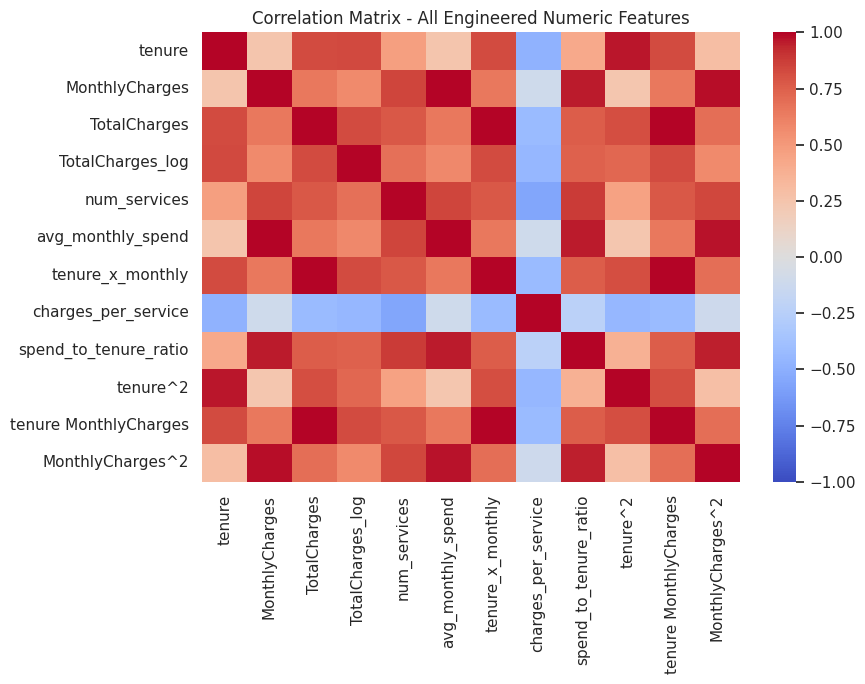

In [12]:
numeric_cols, categorical_cols = get_feature_columns(df, engineered_numeric)
print(f"Final numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Final categorical features ({len(categorical_cols)}): {categorical_cols}")

plt.figure(figsize=(9, 7))
sns.heatmap(df[engineered_numeric].corr(), cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True)
plt.title("Correlation Matrix - All Engineered Numeric Features")
savefig("06_engineered_correlation_matrix")
plt.show()

## 10. Baseline vs. Engineered Feature Set — Model Comparison

To prove the engineered features add real value (not just complexity), a
Logistic Regression is trained on a **minimal baseline** feature set
(raw numeric + a handful of raw categoricals) and compared against the
**same model** trained on the **fully engineered** feature set.

In [13]:
baseline_numeric = BASE_NUMERIC
baseline_categorical = ["gender", "SeniorCitizen", "Partner", "Dependents",
                         "PhoneService", "Contract", "PaymentMethod"]
baseline_df = df[baseline_numeric + baseline_categorical + ["Churn"]]
baseline_split = split_data(baseline_df)
engineered_split = split_data(df)

comparison = compare_feature_sets(
    baseline_numeric, baseline_categorical, baseline_split,
    numeric_cols, categorical_cols, engineered_split,
)
comparison

,baseline_features,engineered_features
accuracy,0.7892,0.8070
precision,0.6207,0.6667
recall,0.5294,0.5455
f1,0.5714,0.6000
roc_auc,0.8363,0.8479


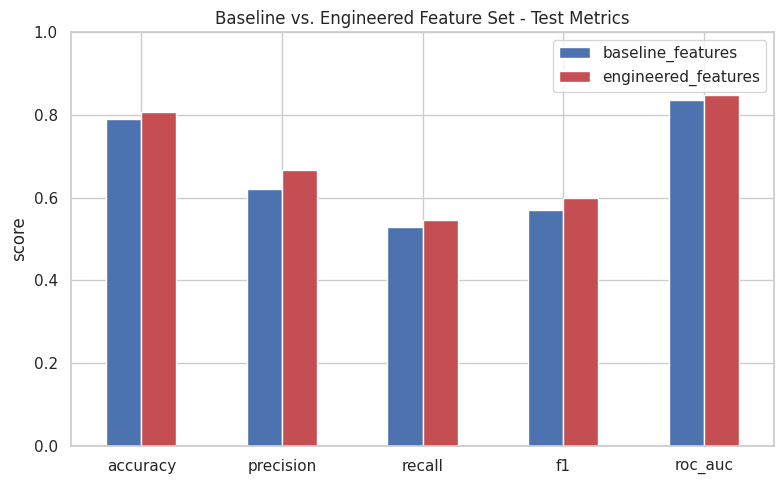

In [14]:
comparison.plot(kind="bar", figsize=(8, 5), color=["#4c72b0", "#c44e52"])
plt.title("Baseline vs. Engineered Feature Set - Test Metrics")
plt.ylabel("score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
savefig("07_baseline_vs_engineered_comparison")
plt.show()

## 11. Feature Importance (Random Forest)

In [15]:
X_train, X_test, y_train, y_test = engineered_split
importance_df = random_forest_feature_importance(numeric_cols, categorical_cols, X_train, y_train, top_n=15)
importance_df

,feature,importance
41,cat__Contract_Month-to-month,0.088783
0,num__tenure,0.073608
9,num__tenure^2,0.067455
7,num__charges_per_service,0.050031
23,cat__OnlineSecurity_No,0.049642
11,num__MonthlyCharges^2,0.043641
2,num__TotalCharges,0.042153
21,cat__InternetService_Fiber optic,0.042063
3,num__TotalCharges_log,0.041570
5,num__avg_monthly_spend,0.040195


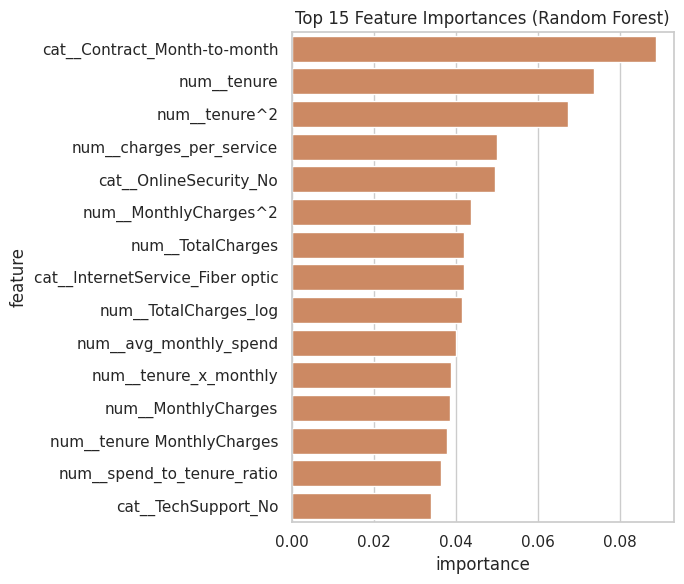

In [16]:
plt.figure(figsize=(7, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#dd8452")
plt.title("Top 15 Feature Importances (Random Forest)")
savefig("08_random_forest_feature_importance")
plt.show()

## 12. Export the Feature-Engineered Dataset

In [17]:
os.makedirs("data/processed", exist_ok=True)
out_path = "data/processed/telco_feature_engineered.csv"
df.to_csv(out_path, index=False)
print(f"Saved feature-engineered dataset to {out_path} - shape {df.shape}")

Saved feature-engineered dataset to data/processed/telco_feature_engineered.csv - shape (7043, 33)


## 13. Summary

- Reduced `TotalCharges` skewness from ~0.96 to ~-0.82 via a log1p transform.
- Added interaction/ratio features (`tenure_x_monthly`, `charges_per_service`,
  `spend_to_tenure_ratio`) and degree-2 polynomial terms on tenure/MonthlyCharges.
- Built a KMeans customer-segment feature and visualized it (and churn) in
  PCA-reduced 2D space.
- Compared one-hot, frequency, and smoothed target encoding on `PaymentMethod`.
- Ranked engineered numeric features by mutual information with churn.
- Directly proved value: the engineered feature set improved ROC-AUC from
  0.836 (baseline) to 0.848, and F1 from 0.571 to 0.600, over an identical
  Logistic Regression.
- Random Forest feature importance confirms `Contract`, `tenure`,
  `tenure^2`, and `charges_per_service` as top predictive signals.
- Exported the final feature-engineered dataset to `data/processed/`.